In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [1]:
import numpy as np 
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 손글씨 데이터셋 
from tensorflow.keras.utils import to_categorical #원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt
# train_test_split 등을 추가 


In [28]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [29]:
print('타겟변수:', data[15,0])
image=data[0,1:].reshape(28,28)
image.shape

타겟변수: 7.0


(28, 28)

In [30]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()#개행

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

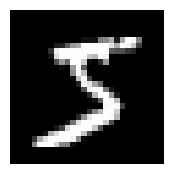

In [31]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# 칼라사진 -> 흑백모드로 넘파이 배열로 읽기 (pip install opencv-python==4.8.1.78)

# conda activate ml-dl-nlp들어가서 설치 pip install opencv-python==4.8pip show opencv-python확인 .1.78 -> pip show opencv-python확인 

In [39]:
import cv2
# 사진 이미지를 흑백 포맷으로 넘파이 배열로 읽어오기 
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

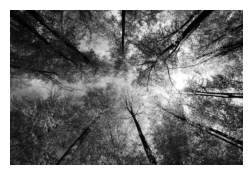

In [40]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

# 1. 데이터 생성 및 전처리 

In [123]:
(X_train, y_train), (X_test, y_test) =mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [113]:
value, counts= np.unique(y_train, return_counts=True)
ratios=counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [114]:
value, counts= np.unique(y_test, return_counts=True)
ratios=counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

7


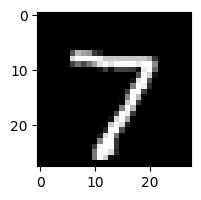

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [115]:
print(y_test[0])
plt.imshow(X_test[0], cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()
        

In [135]:
# Train 데이터 6만개=> train(5만개)+val(만개)로 분리
(X_train, y_train), (X_test, y_test)=mnist.load_data()#6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train=X_train[:50000]
y_train=y_train[:50000]

In [117]:
print('학습셋:', X_train.shape, y_train.shape)
print('검증셋:', X_val.shape, y_val.shape)
print('시험셋:', X_test.shape, y_test.shape)

학습셋: (50000, 28, 28) (50000,)
검증셋: (10000, 28, 28) (10000,)
시험셋: (10000, 28, 28) (10000,)


In [136]:
# 입력(독립)변수 (n, 28,28) -> (n, 28*28)-> 실수 float로 형변환 -> 스케일 조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X = X_val.reshape(10000,784).astype('float32')/255.0
test_X=X_test.reshape(10000,-1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [137]:
#종속 (타겟)변수: 분류 분석을 위한 원핫인코딩 (to_categorical()이용, pd.getdummies)
train_Y=to_categorical(y_train,10)
train_Y[:2]
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [138]:
# Train 50000-> 임의로 700개, val 1만 ->임의로 300개 추출해서 학습(목적:수업시간 중 fit시간 절약)
import random 
#idx = random.sample(range(50000), 700)
train_idx = np.random.choice(50000,700) # 0~50000미만의 700개 수 비복원추출
val_idx = np.random.choice(10000,300)
train_X= train_X[train_idx]
train_Y= train_Y[train_idx]
val_X=  val_X[val_idx]
val_Y = val_Y[val_idx]


In [139]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델구성
# 3. 학습과정 설정 


In [140]:
model=Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 렐루 대신 리키렐루 장착 (음수일 때 1%만 통과)

# 최종 출력층 (이진 분류이므로 시그모이드 유지)
model.add(Dense(units=10, activation='softmax'))

model.summary()
#학습과정 설정:타겟변수를 원핫인코딩 안했다면 sparse_categorical_crossentropy
model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam',
    metrics=['accuracy']#평가지표

)



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_42 (Dense)            (None, 2)                 1570      
                                                                 
 leaky_re_lu_28 (LeakyReLU)  (None, 2)                 0         
                                                                 
 dense_43 (Dense)            (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습

In [141]:
#모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y),
                epochs=200,
                verbose=1
                )

Epoch 1/200
22/22 [==============================] - 1s 15ms/step - loss: 2.2737 - accuracy: 0.1386 - val_loss: 2.2357 - val_accuracy: 0.1400
Epoch 2/200
22/22 [==============================] - 0s 5ms/step - loss: 2.2195 - accuracy: 0.1400 - val_loss: 2.1745 - val_accuracy: 0.1567
Epoch 3/200
22/22 [==============================] - 0s 6ms/step - loss: 2.1658 - accuracy: 0.1386 - val_loss: 2.1238 - val_accuracy: 0.1600
Epoch 4/200
22/22 [==============================] - 0s 5ms/step - loss: 2.1169 - accuracy: 0.1729 - val_loss: 2.0785 - val_accuracy: 0.1933
Epoch 5/200
22/22 [==============================] - 0s 4ms/step - loss: 2.0764 - accuracy: 0.1943 - val_loss: 2.0421 - val_accuracy: 0.2300
Epoch 6/200
22/22 [==============================] - 0s 5ms/step - loss: 2.0403 - accuracy: 0.2314 - val_loss: 2.0094 - val_accuracy: 0.2600
Epoch 7/200
22/22 [==============================] - 0s 5ms/step - loss: 2.0075 - accuracy: 0.2329 - val_loss: 1.9809 - val_accuracy: 0.2900
Epoch 8/200


Epoch 59/200
22/22 [==============================] - 0s 6ms/step - loss: 1.2038 - accuracy: 0.5900 - val_loss: 1.3668 - val_accuracy: 0.5367
Epoch 60/200
22/22 [==============================] - 0s 5ms/step - loss: 1.1948 - accuracy: 0.5929 - val_loss: 1.3627 - val_accuracy: 0.5233
Epoch 61/200
22/22 [==============================] - 0s 5ms/step - loss: 1.1882 - accuracy: 0.5871 - val_loss: 1.3602 - val_accuracy: 0.5233
Epoch 62/200
22/22 [==============================] - 0s 6ms/step - loss: 1.1813 - accuracy: 0.5929 - val_loss: 1.3542 - val_accuracy: 0.5267
Epoch 63/200
22/22 [==============================] - 0s 5ms/step - loss: 1.1717 - accuracy: 0.6057 - val_loss: 1.3478 - val_accuracy: 0.5400
Epoch 64/200
22/22 [==============================] - 0s 5ms/step - loss: 1.1629 - accuracy: 0.6129 - val_loss: 1.3425 - val_accuracy: 0.5367
Epoch 65/200
22/22 [==============================] - 0s 6ms/step - loss: 1.1572 - accuracy: 0.6143 - val_loss: 1.3397 - val_accuracy: 0.5533
Epoch 

22/22 [==============================] - 0s 5ms/step - loss: 0.8750 - accuracy: 0.7300 - val_loss: 1.2505 - val_accuracy: 0.6133
Epoch 117/200
22/22 [==============================] - 0s 5ms/step - loss: 0.8738 - accuracy: 0.7243 - val_loss: 1.2475 - val_accuracy: 0.6033
Epoch 118/200
22/22 [==============================] - 0s 5ms/step - loss: 0.8678 - accuracy: 0.7329 - val_loss: 1.2478 - val_accuracy: 0.6100
Epoch 119/200
22/22 [==============================] - 0s 4ms/step - loss: 0.8643 - accuracy: 0.7300 - val_loss: 1.2473 - val_accuracy: 0.6167
Epoch 120/200
22/22 [==============================] - 0s 5ms/step - loss: 0.8602 - accuracy: 0.7314 - val_loss: 1.2434 - val_accuracy: 0.6000
Epoch 121/200
22/22 [==============================] - 0s 5ms/step - loss: 0.8594 - accuracy: 0.7357 - val_loss: 1.2532 - val_accuracy: 0.6133
Epoch 122/200
22/22 [==============================] - 0s 5ms/step - loss: 0.8546 - accuracy: 0.7300 - val_loss: 1.2505 - val_accuracy: 0.6033
Epoch 123/200

22/22 [==============================] - 0s 5ms/step - loss: 0.7220 - accuracy: 0.7757 - val_loss: 1.2931 - val_accuracy: 0.6000
Epoch 174/200
22/22 [==============================] - 0s 5ms/step - loss: 0.7205 - accuracy: 0.7729 - val_loss: 1.2965 - val_accuracy: 0.6067
Epoch 175/200
22/22 [==============================] - 0s 5ms/step - loss: 0.7188 - accuracy: 0.7743 - val_loss: 1.2991 - val_accuracy: 0.6000
Epoch 176/200
22/22 [==============================] - 0s 5ms/step - loss: 0.7153 - accuracy: 0.7771 - val_loss: 1.2967 - val_accuracy: 0.6100
Epoch 177/200
22/22 [==============================] - 0s 6ms/step - loss: 0.7136 - accuracy: 0.7743 - val_loss: 1.3141 - val_accuracy: 0.6133
Epoch 178/200
22/22 [==============================] - 0s 5ms/step - loss: 0.7127 - accuracy: 0.7729 - val_loss: 1.2998 - val_accuracy: 0.5900
Epoch 179/200
22/22 [==============================] - 0s 6ms/step - loss: 0.7109 - accuracy: 0.7771 - val_loss: 1.3095 - val_accuracy: 0.6100
Epoch 180/200

# 5. 모델평가하기

In [142]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [ ]:
# 학습과정 살펴보기(시각화)


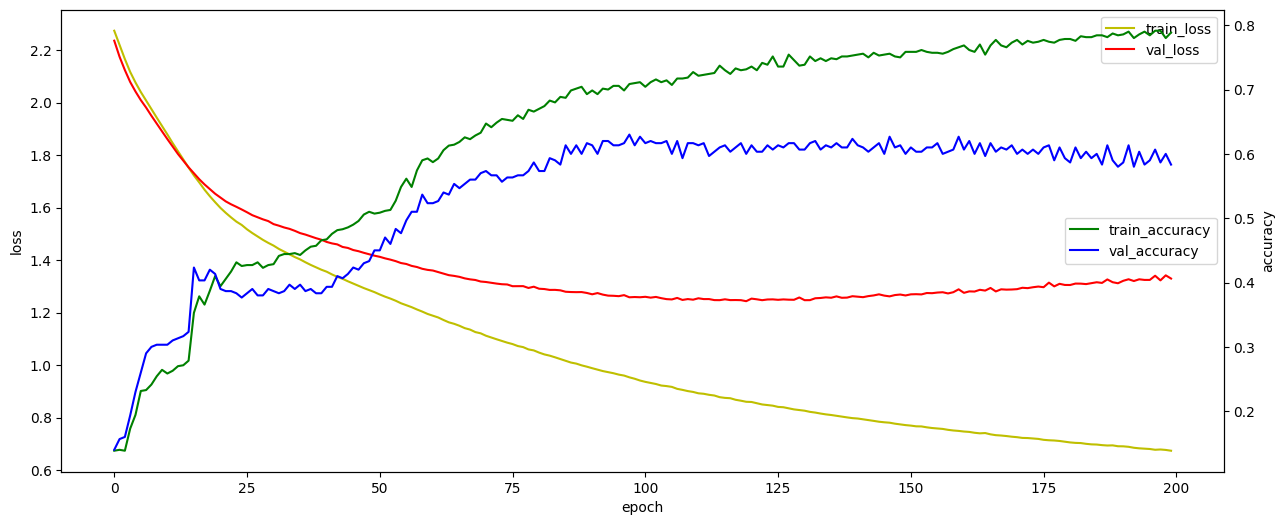

In [143]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [144]:
#모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss:', loss_metrics[0])
print('accuracy:', loss_metrics[1])

loss: 1.4879199266433716
accuracy: 0.5837000012397766


# 👍위 모델(DNN)의 accuracy 늘리기 
- 데이터 확보 
- 모델 수정 (레이어 추가, units수 증가)
- 과적합 방지 (validation data 추가, 활성화함수를 relu계열, tahn, Dropout추가, 배치정규화, L2정규화(규제...)
- epoch 조정
- optimiser 변경 

In [5]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# # Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
# val_idx   = np.random.choice(10000, 300)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# val_X   = val_X[val_idx]
# val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성 (784->1024->512->128->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=1024))
model.add(BatchNormalization()) #1024개 출력층을 배치 정규화 
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dropout(0.2))

model.add(Dense(units=512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=128, activation='relu'))
model.add(BatchNormalization()) #과적값을 줄이려고 
model.add(Dropout(0.1))#과적값을 줄이려고 

model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, #크면 학습속도는 빨라지나 메모리 부족이 뜰수 있다. 
                epochs=30, 
                verbose=2
                )

(50000, 784) (50000, 10) (10000, 784) (10000, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 1024)              803840    
                                                                 
 batch_normalization_1 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 1024)              0         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_6 (Dense)             (None, 512)               524800    
                                                                 
 batch_normalization_2 (Batc  (None, 512)      

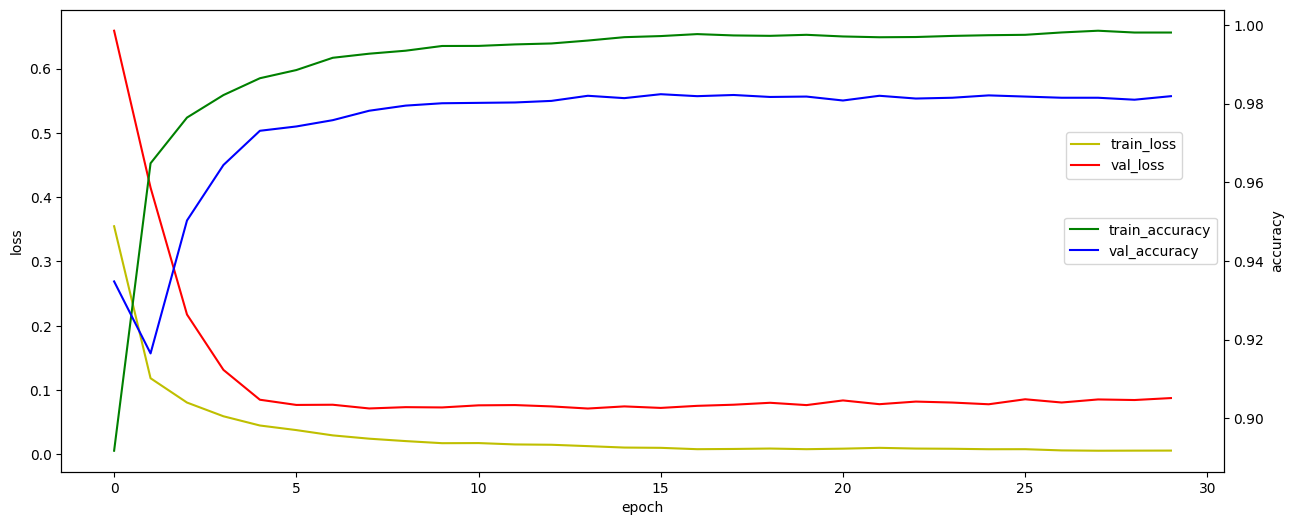

loss : 0.08019394427537918
accuracy : 0.9804999828338623


In [6]:

# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

In [9]:
# 교차표 
y_test #실제값
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1)==y_test)

True

In [11]:
y_hat = model.predict(test_X).argmax(axis=1) #예측값
y_hat = np.argmax(model.predict(test_X), axis=1)
y_hat

313/313 [==============================] - 2s 5ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [12]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,974,1,0,0,0,1,2,1,1,0
1,0,1131,1,0,0,1,1,0,1,0
2,3,1,1016,1,0,0,1,7,3,0
3,1,0,4,994,0,3,0,4,4,0
4,1,3,2,1,951,0,3,4,1,16
5,2,0,0,12,1,864,9,1,1,2
6,3,4,0,1,2,3,944,0,1,0
7,1,9,7,2,0,0,0,1004,1,4
8,3,0,4,4,1,2,1,4,952,3


In [14]:
#틀린갯수
from sklearn.metrics import confusion_matrix
accuracy = loss_metrics[1]
10000-10000*accuracy


195.00017166137695

# ※콜백함수

In [ ]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)

# 모델생성 (784->2->10)및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과

model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, #크면 학습속도는 빨라지나 메모리 부족이 뜰수 있다. 
                epochs=30, 
                verbose=2
                )